# Híbrido con variables de contenido, versión reducida (NCF + TMDB)

En este cuadernillo se repite el modelo híbrido de RNhybrid.ipynb (NCF + variables de contenido de TMDB), pero usando menos variables: se excluyen popularity, vote_average y vote_count, y solo se mantienen year, runtime y los géneros. El objetivo es ver si esas variables de TMDB (que no siempre están disponibles o son fiables) son realmente necesarias.

Fuente: curso de PyTorch de Datacamp

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import random
import matplotlib.pyplot as plt

Se fijan las semillas aleatorias para que el entrenamiento sea reproducible.

## Carga y preparación de datos

In [2]:
random.seed(73)
np.random.seed(73)
torch.manual_seed(73)
torch.cuda.manual_seed_all(73) #si hay gpu

Se carga hybrid.parquet, que combina para cada valoración:
- MovieLens: userId, rating, movieId, year, genres, timestamp
- TMDB: id, budget, popularity, vote_average, vote_count, revenue, runtime

In [3]:
df = pd.read_parquet("../../data/03_model_ready/hybrid.parquet").sort_values('movieId')

In [4]:
columnas = df.columns
columnas

Index(['userId', 'movieId', 'timestamp', 'rating', 'genres', 'year',
       'popularity', 'vote_average', 'vote_count', 'runtime',
       '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 100505 entries, 94039 to 104
Data columns (total 30 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   userId              100505 non-null  int64         
 1   movieId             100505 non-null  int64         
 2   timestamp           100505 non-null  datetime64[ms]
 3   rating              100505 non-null  float64       
 4   genres              100505 non-null  object        
 5   year                100505 non-null  Int64         
 6   popularity          100505 non-null  float64       
 7   vote_average        100505 non-null  float64       
 8   vote_count          100505 non-null  int64         
 9   runtime             100505 non-null  int64         
 10  (no genres listed)  100505 non-null  int64         
 11  Action              100505 non-null  int64         
 12  Adventure           100505 non-null  int64         
 13  Animation           100505 non-null  int64  

Se elimina la columna genres de texto, ya que los géneros ya están codificados como columnas binarias (Action, Adventure, Comedy...).

In [6]:
df =  df.drop(columns=['genres'])

Se comprueba cuántas películas ha valorado cada usuario: todos tienen un mínimo de 20.

In [7]:
peliculasPorUsuario = (df.groupby('userId').size().reset_index(name='numPeliculas').sort_values('numPeliculas', ascending=True))
peliculasPorUsuario
# todos tienen minimo 20 peliculas valoradas

,userId,numPeliculas
594,595,20
52,53,20
568,569,20
575,576,20
319,320,20
...,...,...
273,274,1343
447,448,1861
473,474,2103
598,599,2448


## Transformaciones logarítmicas
Veamos si es necesario aplicar transformaciones logarítmicas a las variables numéricas de contenido, para corregir distribuciones muy asimétricas. Este análisis es el mismo que en RNhybrid.ipynb; se mantiene aquí aunque popularity, vote_average y vote_count no acaben usándose como variables del modelo en esta versión.

In [8]:
df[['popularity','vote_average', 'vote_count', 'runtime' , 'year']].describe()

,popularity,vote_average,vote_count,runtime,year
count,100505.000000,100505.000000,100505.000000,100505.000000,100505.0
mean,7.943277,7.039492,6266.566439,114.575225,1994.422556
std,11.065159,0.801777,7170.891775,24.045922,14.360523
min,0.003500,0.000000,0.000000,2.000000,1902.0
25%,2.595900,6.514000,1179.000000,98.000000,1990.0
50%,4.774000,7.100000,3506.000000,111.000000,1997.0
75%,8.893600,7.600000,8922.000000,127.000000,2003.0
max,134.778800,8.894000,39920.000000,583.000000,2018.0


Posibles variables a las que aplicar la transformación: popularity y vote_count. A year no se le aplica ninguna transformación.

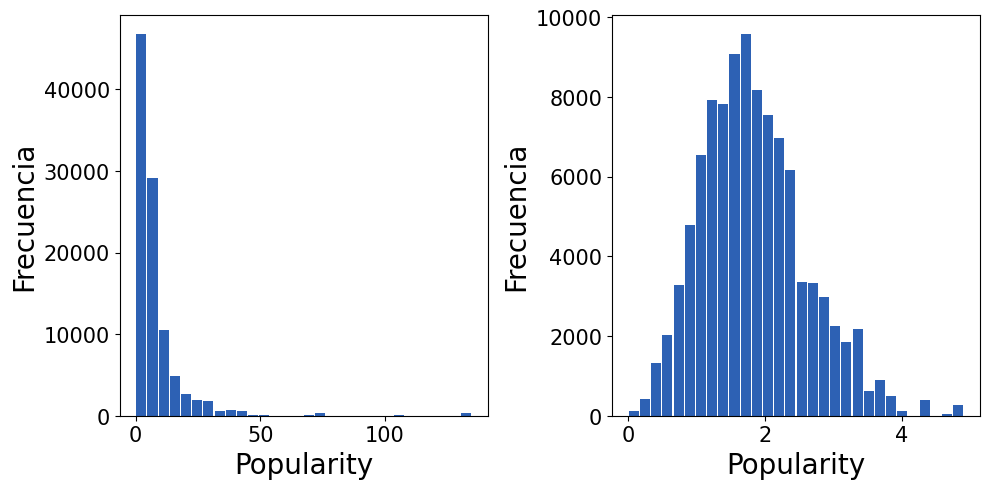

In [9]:
# popularity 
valores = df['popularity']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('Popularity', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores+1),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('Popularity', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

distribución sesgada a la derecha. Al aplicar log se corrige la asimetría. Tiene sentido aplicar la transformación

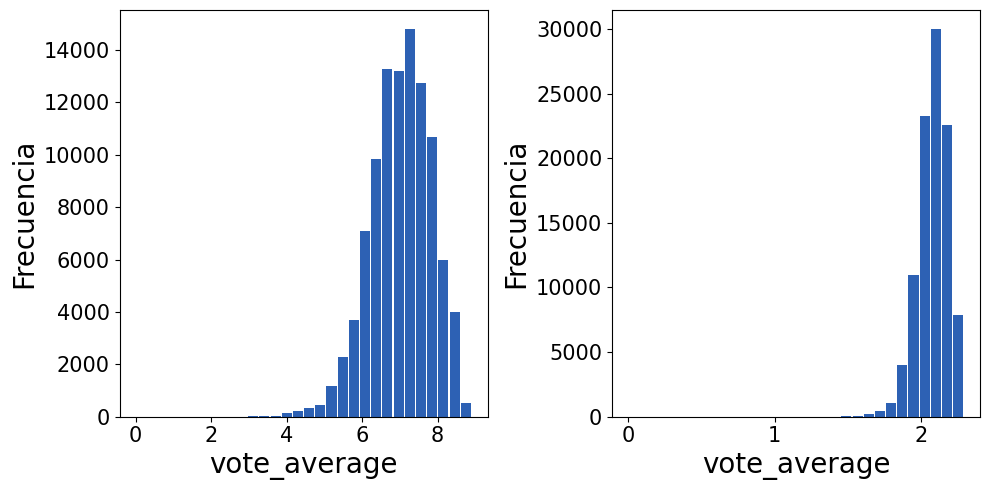

In [10]:
# vote_average
valores = df['vote_average']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('vote_average', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores +1),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('vote_average', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

NO tiene sentido una transformación logarítmica en este caso. Distribución sesgada a la izquierda y datos acotados. 

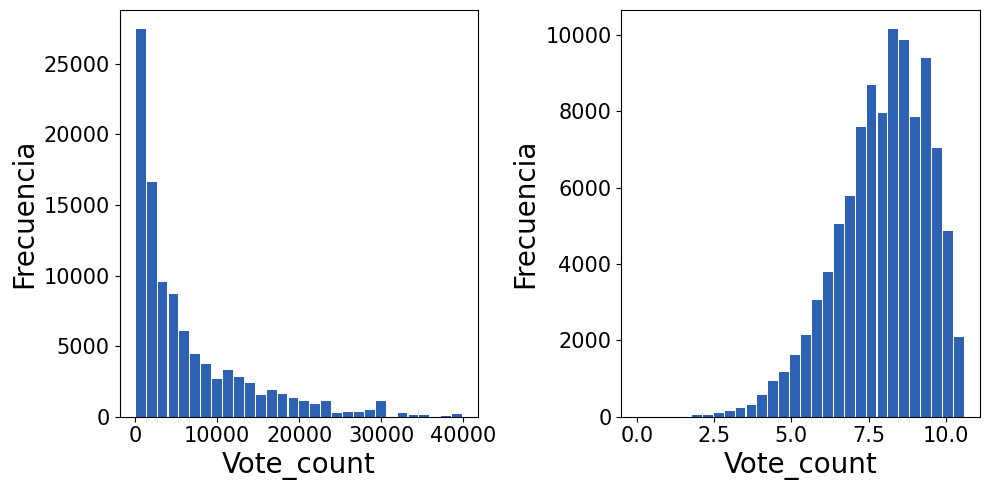

In [11]:
# vote_count
valores = df['vote_count']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('Vote_count', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores +1),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('Vote_count', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

Sí tiene sentido la transformación

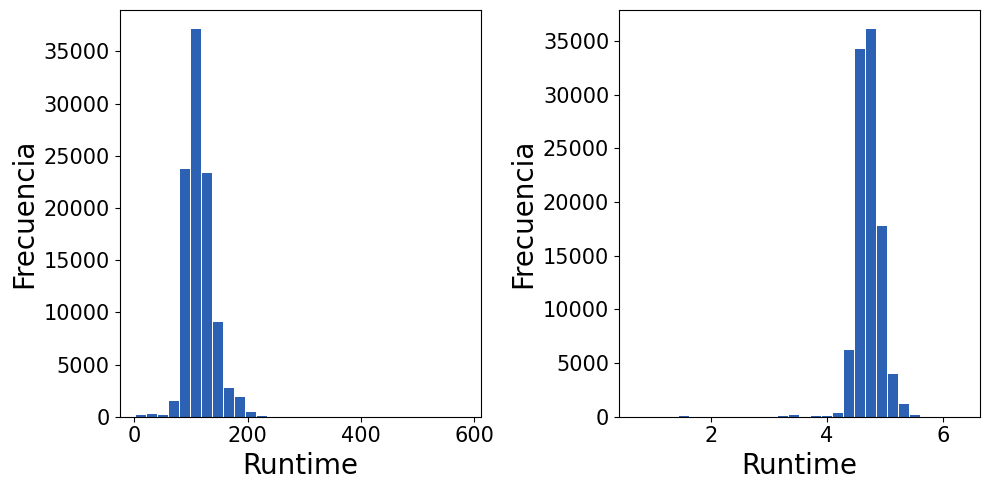

In [12]:
# runtime 
valores = df['runtime']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('Runtime', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('Runtime', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

No aporta nada la transformación.

Se aplica transformación a Popularity y vote_count.

In [13]:
df['popularity']= np.log(df['popularity']+1)
df['vote_count']= np.log(df['vote_count']+1)

## Partición en train, val y test
Partición preliminar por usuario y de forma temporal (70/15/15), igual que en el resto de modelos. Más adelante se repite este mismo proceso tras eliminar la columna timestamp, y esa segunda partición es la que se usa realmente en el resto del cuadernillo.

In [14]:
# PARTICIÓN TRAIN /VAL / TEST.
train = pd.DataFrame()
val   = pd.DataFrame()
test  = pd.DataFrame()

# dfUser = pd.read_parquet("../../../data/02_silver/ratingsFinal.parquet")
dfUser = df.sort_values(['userId', 'timestamp'])

def particion(ratingsUser):
    global train, val, test
    n       = len(ratingsUser)
    p_train = round(n * 0.70)
    p_val   = round(n * 0.85)

    trainPar = ratingsUser.head(p_train)
    valPar   = ratingsUser.iloc[p_train:p_val]
    testPar  = ratingsUser.tail(n - p_val)

    train = pd.concat([train, trainPar], ignore_index=True)
    val   = pd.concat([val,   valPar],   ignore_index=True)
    test  = pd.concat([test,  testPar],  ignore_index=True)

for i in dfUser['userId'].unique():
    particion(dfUser[dfUser['userId'] == i])

print(f"Train: {len(train)} ratings")
print(f"Val:   {len(val)} ratings")
print(f"Test:  {len(test)} ratings")

Train: 70342 ratings
Val:   15103 ratings
Test:  15060 ratings


Las variables numéricas se normalizan (media 0, desviación 1) para que todas tengan la misma escala: popularity, vote_average, vote_count, runtime y year. La media y la desviación se calculan sobre train y se aplican después a los tres conjuntos (aunque de estas, en esta versión reducida solo runtime y year acaban usándose como variables del modelo).

## Preparación para la red NCF

Fuente: https://www.geeksforgeeks.org/deep-learning/neural-collaborative-filtering/

Las capas de embedding de PyTorch necesitan índices consecutivos empezando en 0, y los IDs originales de usuarios y películas no lo son. Por eso se construye un diccionario que traduce cada userId y cada movieId a un índice consecutivo.

In [15]:
# índices consecutivos para usuarios
userIndice = {}
i = 0

for user in df["userId"].unique():
    userIndice[user] = i
    i += 1

In [16]:
# índices consecutivos para películas
movieIndice = {}
i = 0

for movie in df["movieId"].unique():
    movieIndice[movie] = i
    i += 1

In [17]:
df["userIndice"] = df["userId"].map(userIndice)
df["movieIndice"] = df["movieId"].map(movieIndice)

In [18]:
df.sort_values('userId')

,userId,movieId,timestamp,rating,year,popularity,vote_average,vote_count,runtime,(no genres listed),...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,userIndice,movieIndice
594,1,1793,2000-07-30 18:23:24,4.0,1997,0.545517,5.794,3.555348,106,0,...,0,0,0,0,0,0,0,0,15,1322
44422,1,2395,2000-07-30 18:18:13,5.0,1998,1.237388,7.395,7.912423,93,0,...,0,0,0,0,0,0,0,0,15,1792
90992,1,2028,2000-07-30 18:31:28,4.0,1998,2.939432,8.226,9.756031,169,0,...,0,0,0,0,0,0,1,0,15,1499
68255,1,500,2000-07-30 18:20:08,3.0,1993,1.892344,7.200,8.798304,125,0,...,0,0,0,0,0,0,0,0,15,436
40469,1,2991,2000-07-30 18:37:51,5.0,1973,1.510369,6.500,7.734996,121,0,...,0,0,0,0,0,1,0,0,15,2247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68157,610,104241,2016-11-19 08:38:29,3.0,2013,1.584387,6.405,8.792853,103,0,...,0,0,0,0,0,0,0,0,149,8141
75911,610,608,2016-11-19 08:08:53,4.5,1996,2.032848,7.849,9.116030,98,0,...,0,0,0,0,0,1,0,0,149,520
56581,610,104243,2017-05-03 21:10:45,3.5,2013,1.871494,6.300,8.392537,119,0,...,1,0,0,0,1,1,0,0,149,8142
55896,610,103810,2017-05-03 21:41:23,3.0,2013,1.785070,6.500,8.371705,116,0,...,0,0,0,0,0,1,0,0,149,8126


Se repite la partición en train, val y test, esta vez sobre df ya con los índices de usuario/película añadidos y sin la columna timestamp (no se necesita como variable del modelo). Esta es la partición que se usa en el resto del cuadernillo.

In [19]:
# PARTICIÓN TRAIN /VAL / TEST.
train = pd.DataFrame()
val   = pd.DataFrame()
test  = pd.DataFrame()

# dfUser = pd.read_parquet("../../../data/02_silver/ratingsFinal.parquet")
dfUser = df.sort_values(['userId', 'timestamp'])
dfUser=dfUser.drop(columns=['timestamp'])
def particion(ratingsUser):
    global train, val, test
    n       = len(ratingsUser)
    p_train = round(n * 0.70)
    p_val   = round(n * 0.85)

    trainPar = ratingsUser.head(p_train)
    valPar   = ratingsUser.iloc[p_train:p_val]
    testPar  = ratingsUser.tail(n - p_val)

    train = pd.concat([train, trainPar], ignore_index=True)
    val   = pd.concat([val,   valPar],   ignore_index=True)
    test  = pd.concat([test,  testPar],  ignore_index=True)

for i in dfUser['userId'].unique():
    particion(dfUser[dfUser['userId'] == i])

print(f"Train: {len(train)} ratings")
print(f"Val:   {len(val)} ratings")
print(f"Test:  {len(test)} ratings")

Train: 70342 ratings
Val:   15103 ratings
Test:  15060 ratings


Se calculan media y desviación típica de las variables numéricas sobre train, y se usan para normalizar train, val y test.

In [20]:
columnasNorm = ['popularity','vote_average', 'vote_count', 'runtime' , 'year']
media = train[columnasNorm].mean()
std = train[columnasNorm].std()

In [21]:
train[columnasNorm] =  (train[columnasNorm]-media)/std
val[columnasNorm] =  (val[columnasNorm]-media)/std
test[columnasNorm] =  (test[columnasNorm]-media)/std

Se define la lista variables: las columnas de contenido que se usarán como entrada adicional de la red, junto a los embeddings de usuario y película. A diferencia de RNhybrid.ipynb, aquí se excluyen popularity, vote_average y vote_count, quedando solo year, runtime y los géneros binarios.

In [22]:
columnas = ['userId', 'movieId', 'rating', 'year', 'popularity',
       'vote_average', 'vote_count', 'runtime','(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'userIdice',
       'movieIndice']




#  variables predictoras del modelo
variables =  ['year','runtime','(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


El rating se escala al intervalo [0, 1], ya que la red termina con una sigmoide, cuya salida está en ese rango.

In [23]:
train['rating_norm'] = train['rating'] / 5.0
val['rating_norm']   = val['rating'] / 5.0
test['rating_norm']  = test['rating'] / 5.0

Número total de usuarios y de películas, necesario para definir el tamaño de las capas de embedding.

In [24]:
numUsers = df['userIndice'].max() + 1
numItems = df['movieIndice'].max() + 1

## Modelo híbrido con menos variables
Se define un Dataset de PyTorch que, para cada valoración, devuelve el índice del usuario, el índice de la película, el vector de variables de contenido (X, ahora reducido) y el rating normalizado.

In [25]:
class RedesDataSet(Dataset):
    def __init__(self,df):
        super().__init__()
        self.userInd = torch.tensor(df['userIndice'].values, dtype=torch.long)
        self.movieInd = torch.tensor(df['movieIndice'].values, dtype=torch.long)
        self.X = torch.from_numpy(df[variables].values.astype(np.float32))
        self.y = torch.from_numpy(df['rating_norm'].values.astype(np.float32))
       
    def __getitem__(self, ind):
        return self.userInd[ind], self.movieInd[ind],self.X[ind], self.y[ind]  
   
    def __len__(self):
        return self.y.shape[0]

Se crean los datasets y dataloaders de train, val y test. Además, dataset_train_val (y su dataloader) combina train y val, y se usará más adelante para reentrenar el modelo final con toda la información disponible antes de evaluar sobre test.

In [26]:
dataset_train = RedesDataSet(train)
dataset_val  = RedesDataSet(val)
dataset_test  = RedesDataSet(test)
dataset_train_val = RedesDataSet(pd.concat([train, val]))
dataloader_train= DataLoader(dataset_train, batch_size=200, shuffle=True)
dataloader_val   = DataLoader(dataset_val,   batch_size=200, shuffle=False)
dataloader_test  = DataLoader(dataset_test,  batch_size=200, shuffle=False)
dataloader_train_val = DataLoader(dataset_train_val, batch_size=200, shuffle=True)

La arquitectura es la misma que en RNcol.ipynb y RNhybrid.ipynb, pero antes de la primera capa totalmente conectada se concatenan también las numVar variables de contenido (X_feat, ahora menos numerosas), junto a los embeddings de usuario y película.

In [27]:
class NCF(nn.Module):
    def __init__(self, numUsers,numItems,numVar,dropout,embedDim):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(numUsers, embedDim)
        self.item_embedding = nn.Embedding(numItems, embedDim)
        self.fc1 = nn.Linear(embedDim*2+numVar, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, user, item, X_feat):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb, X_feat], dim=-1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x.squeeze()

In [28]:
numVar=len(variables)

In [29]:
import copy

## Entrenamiento
La función entrenaRed entrena el modelo con el optimizador Adam y early stopping: en cada época se calcula la pérdida (MSE) en train y en val, y se guarda una copia del mejor modelo según la pérdida de validación. Si la validación no mejora durante early_stop épocas seguidas, se detiene el entrenamiento. Además, se guarda la evolución de la pérdida en train y val para poder graficarla después.

In [30]:
def  entrenaRed(lr,wd,dropout,epoca, early_stop,tam_embedd):
    criterion = nn.MSELoss()
    model =NCF(numUsers,numItems,numVar,dropout,tam_embedd)
    optimizer =optim.Adam(model.parameters(), lr=lr,weight_decay=wd)

    best_val = float('inf')
    best_model = None


    #  gráfico
    train_graf = []
    val_graf = []

    # parada
    stop = 0
    print(f"Entrenamiento con parámetros: lr={lr}, wd={wd}, drop={dropout}, época={epoca}, early_stop={early_stop}, dim_embed={tam_embedd}")
    for epoch in range(epoca):
        model.train()
        train_loss = 0
        for user, item,X, y in dataloader_train:
            optimizer.zero_grad()
            pred= model(user, item,X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dataloader_train)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for user, item,X, y in dataloader_val:
                pred =model(user, item,X)
                loss= criterion(pred, y)
                val_loss += loss.item()
        val_loss /= len(dataloader_val)

        train_graf.append(train_loss)
        val_graf.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_model = copy.deepcopy(model) #lo guarda en RAM
            stop = 0
        else:
            stop +=1 

        if (epoch + 1) %5 ==0:
            print(f"Epoch {epoch+1} |Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")
        epoca_parada=100    
        if stop >= early_stop:
            epoca_parada = epoch+1
            print(f"Early stopping en la época: {epoch+1}")
            break
        # print(f"Mejor RMSE en validación: {(best_val**0.5)*5:.4f}")
    return  best_model,best_val, train_graf,val_graf,epoca_parada


In [31]:
from matplotlib.ticker import MaxNLocator

graficaEntrenamiento convierte la pérdida (MSE en escala normalizada) a RMSE en la escala original del rating (multiplicando por 5), y dibuja su evolución por época para train y val. La gráfica se guarda como imagen en la carpeta graficoRMHybridMenos.

In [ ]:
def graficaEntrenamiento(train_graf,val_graf, lr,wd, drop,n,tam_embedd):
    train_graf_RMSE = (np.array(train_graf)**0.5)*5
    val_graf_RMSE = (np.array(val_graf)**0.5)*5
    
    plt.figure()
    plt.plot(train_graf_RMSE,label="Entrenamiento",linewidth=5)
    plt.plot(val_graf_RMSE,label="Validación",linewidth=5)
    plt.xlabel('Épocas', fontsize=20)
    plt.ylabel('RMSE', fontsize=20)
    plt.xticks(fontsize=18)
  

    # ymax = int(np.ceil(max(np.max(train_graf_RMSE), np.max(val_graf_RMSE))))
    plt.yticks( fontsize=18)

    plt.legend()
    plt.title(f"lr = {lr}, wd = {wd}, dropout = {drop}\n" 
              f"dim. embeddings = {tam_embedd}", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"graficoRMHybridMenos/{n}.png")
    plt.show()
    return f"{n}.png"


## Búsqueda de hiperparámetros
Se entrena el modelo para todas las combinaciones de dimensión de embedding (32, 64), learning rate, weight decay y dropout, guardando para cada una el mejor RMSE de validación y la gráfica de entrenamiento correspondiente.

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.023 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.019 | Val Loss: 0.035
Epoch 20 |Train Loss: 0.017 | Val Loss: 0.037
Early stopping en la época: 20


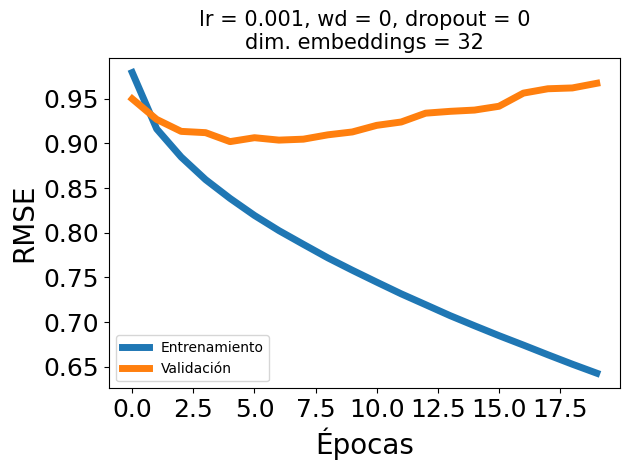

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.031 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 20 |Train Loss: 0.023 | Val Loss: 0.032
Epoch 25 |Train Loss: 0.022 | Val Loss: 0.033
Early stopping en la época: 28


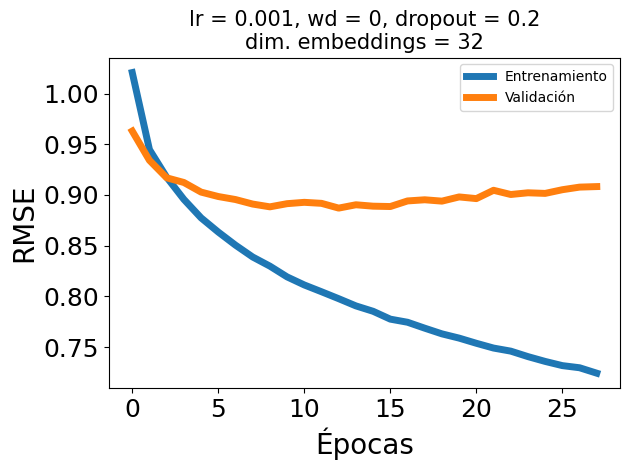

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.032 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.028 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.026 | Val Loss: 0.032
Epoch 20 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 25 |Train Loss: 0.024 | Val Loss: 0.032
Epoch 30 |Train Loss: 0.023 | Val Loss: 0.032
Epoch 35 |Train Loss: 0.023 | Val Loss: 0.033
Early stopping en la época: 36


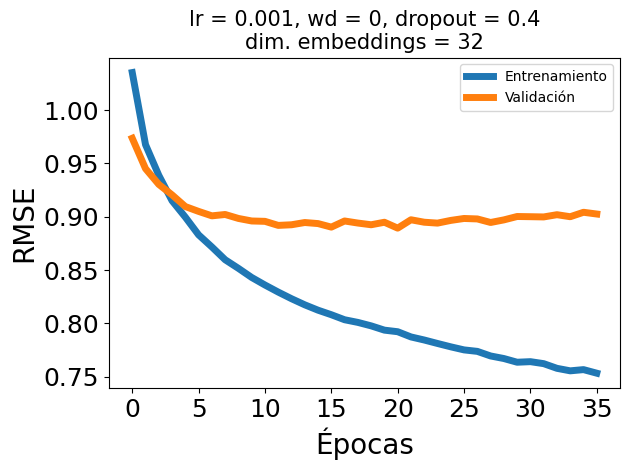

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


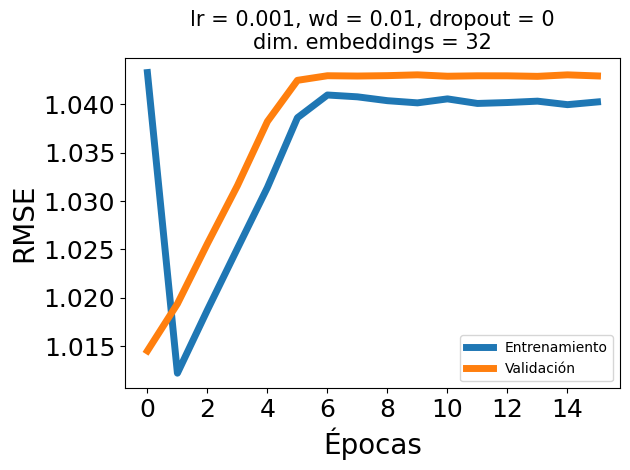

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


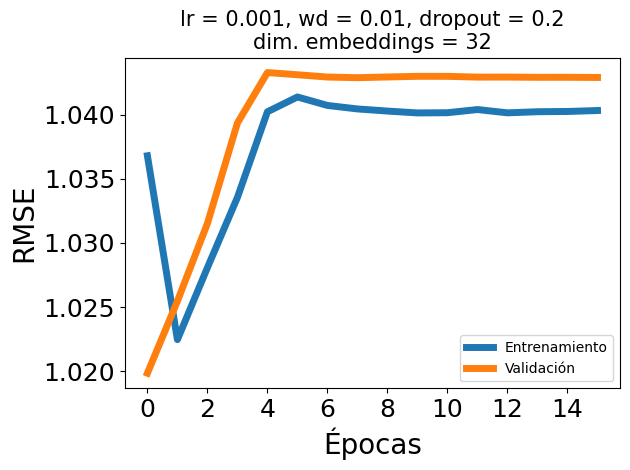

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


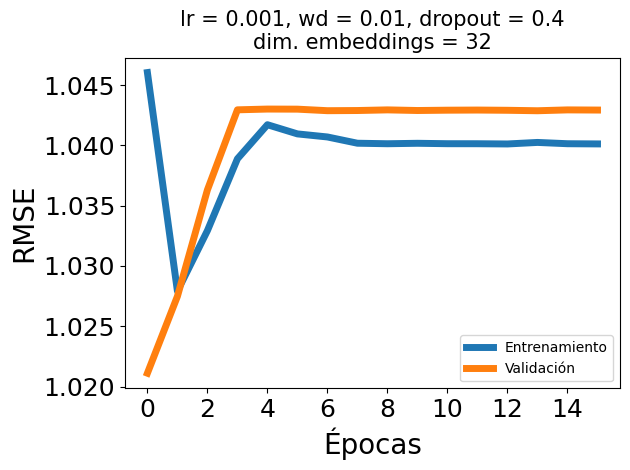

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.031
Epoch 15 |Train Loss: 0.016 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.012 | Val Loss: 0.036
Early stopping en la época: 24


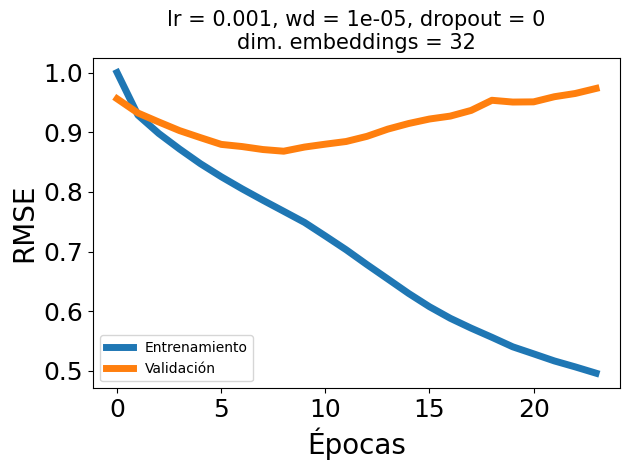

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.030 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.021 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.018 | Val Loss: 0.031
Epoch 25 |Train Loss: 0.016 | Val Loss: 0.032
Early stopping en la época: 26


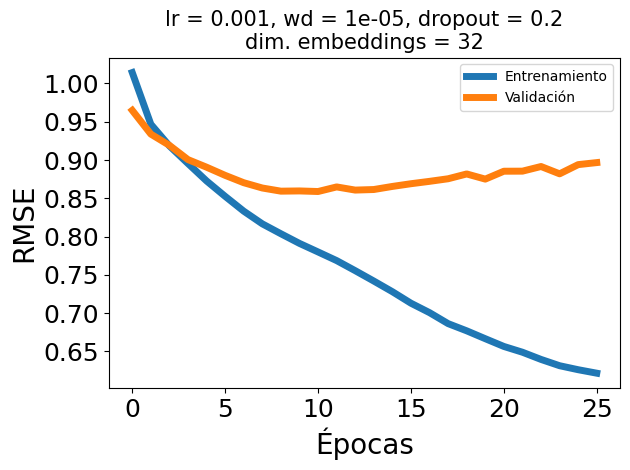

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.032 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.022 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.021 | Val Loss: 0.031
Early stopping en la época: 29


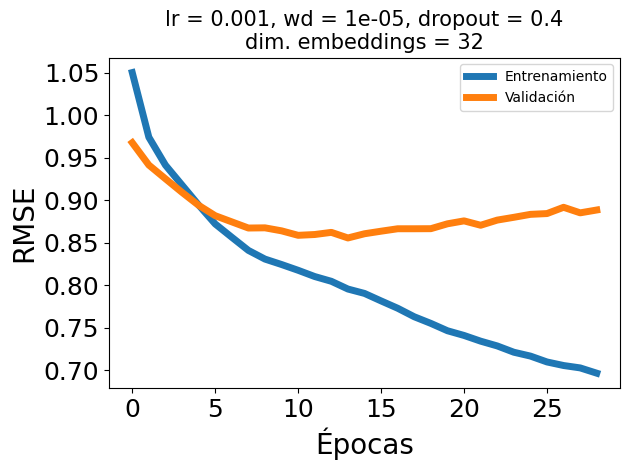

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.024 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.017 | Val Loss: 0.037
Epoch 15 |Train Loss: 0.012 | Val Loss: 0.040
Early stopping en la época: 18


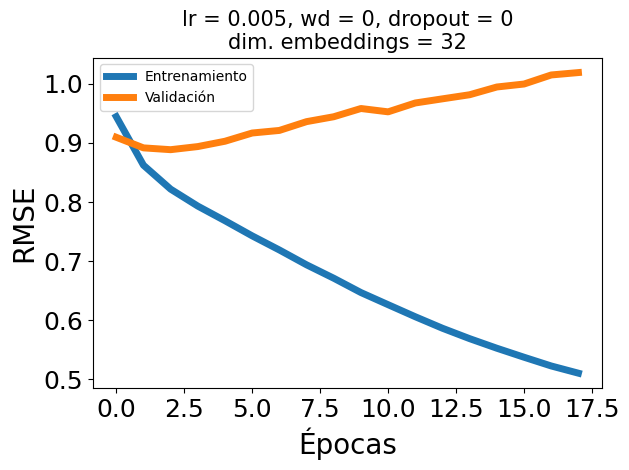

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.034
Epoch 15 |Train Loss: 0.019 | Val Loss: 0.034
Epoch 20 |Train Loss: 0.017 | Val Loss: 0.035
Early stopping en la época: 20


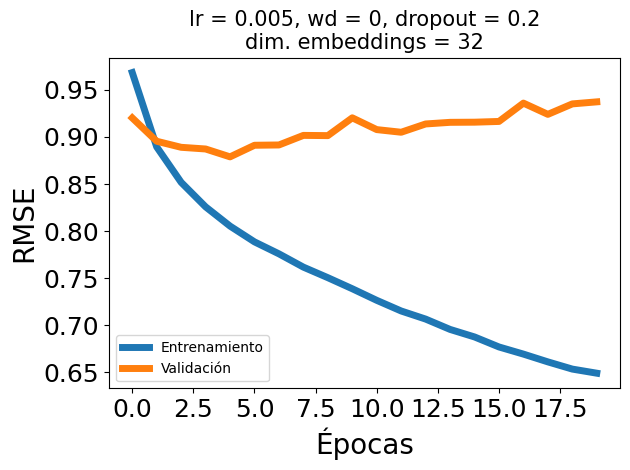

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.023 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.021 | Val Loss: 0.034
Early stopping en la época: 20


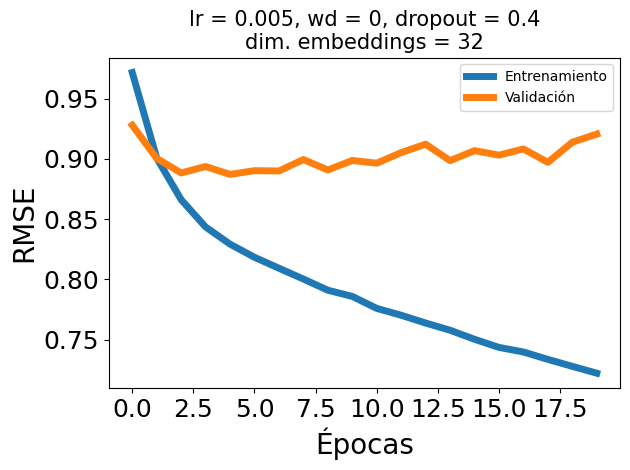

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


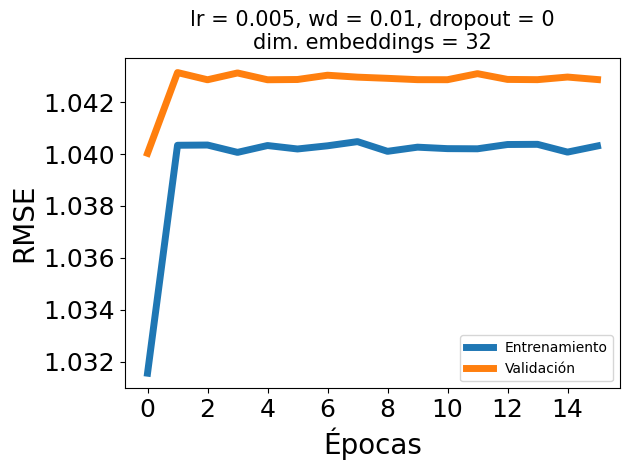

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


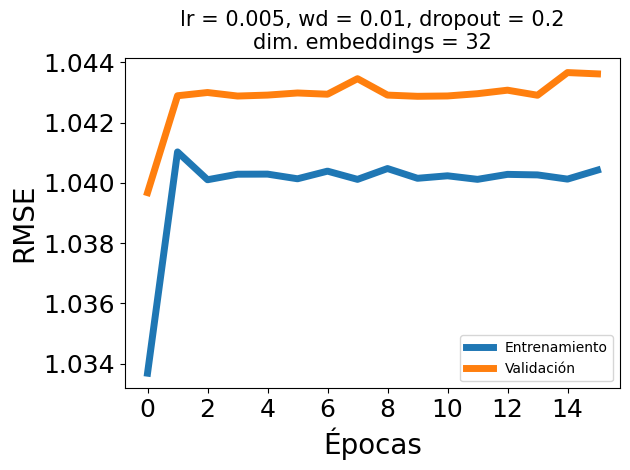

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


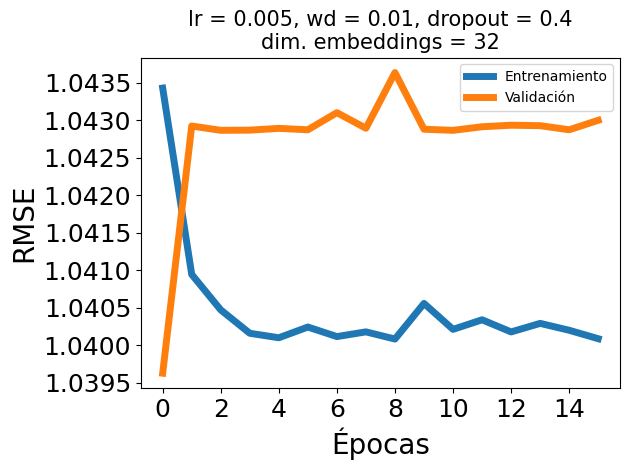

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.019 | Val Loss: 0.031
Epoch 20 |Train Loss: 0.018 | Val Loss: 0.031
Early stopping en la época: 22


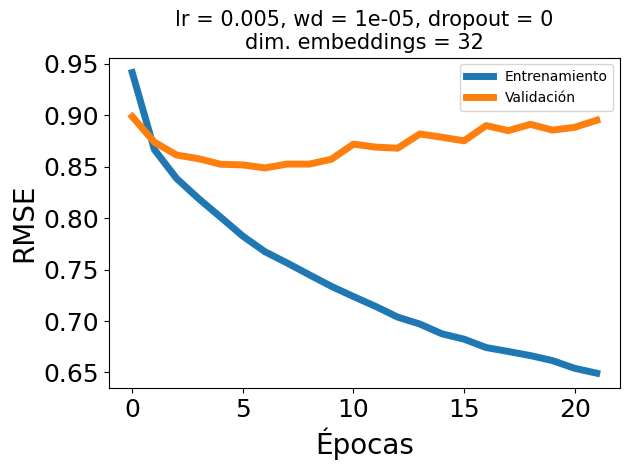

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.022 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.021 | Val Loss: 0.031
Early stopping en la época: 26


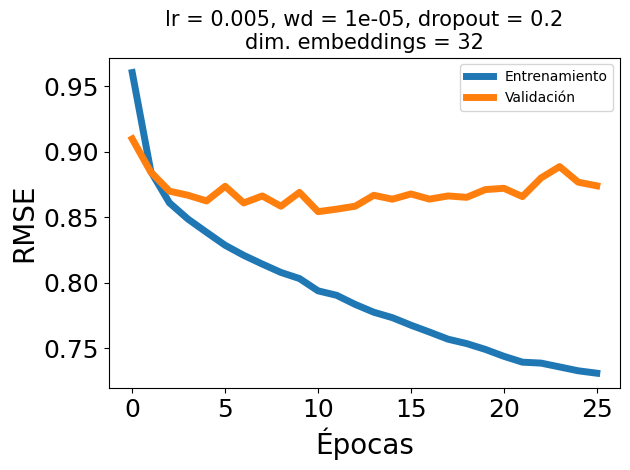

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.030 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.025 | Val Loss: 0.031
Epoch 30 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 35 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 40 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 45 |Train Loss: 0.023 | Val Loss: 0.031
Early stopping en la época: 45


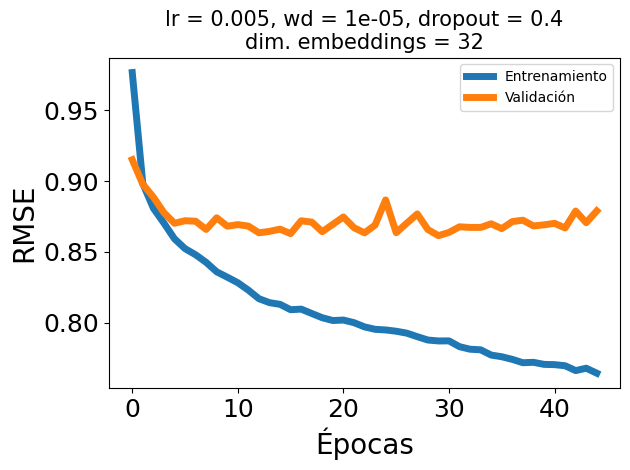

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.022 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.014 | Val Loss: 0.036
Epoch 15 |Train Loss: 0.010 | Val Loss: 0.039
Early stopping en la época: 18


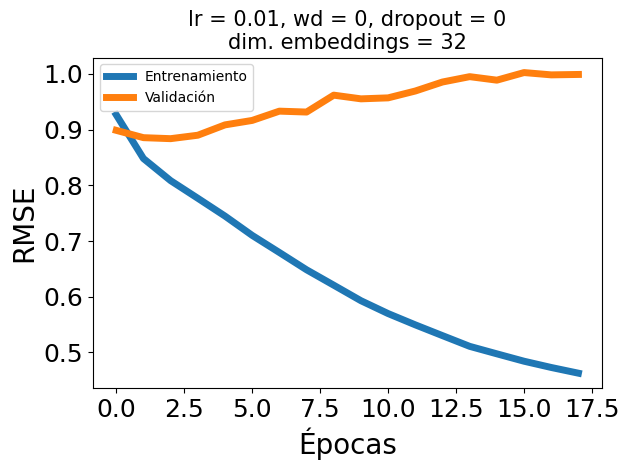

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.021 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.018 | Val Loss: 0.034
Early stopping en la época: 17


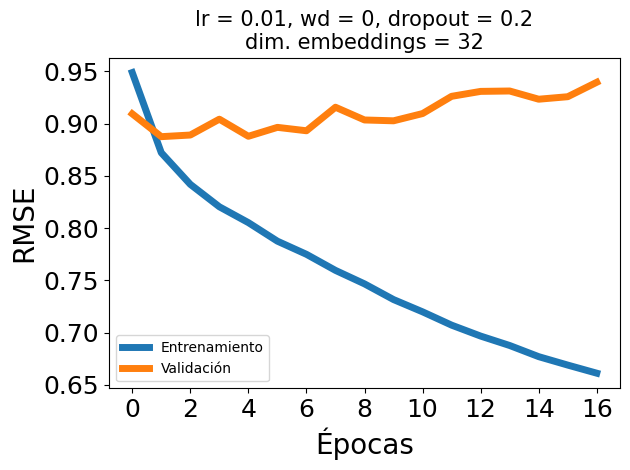

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.023 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.021 | Val Loss: 0.033
Early stopping en la época: 20


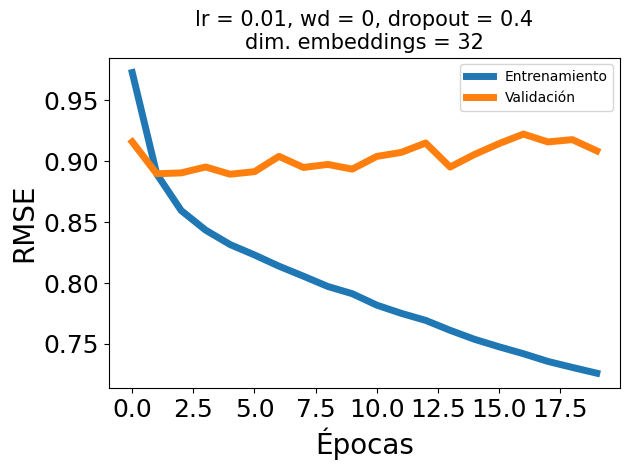

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 23


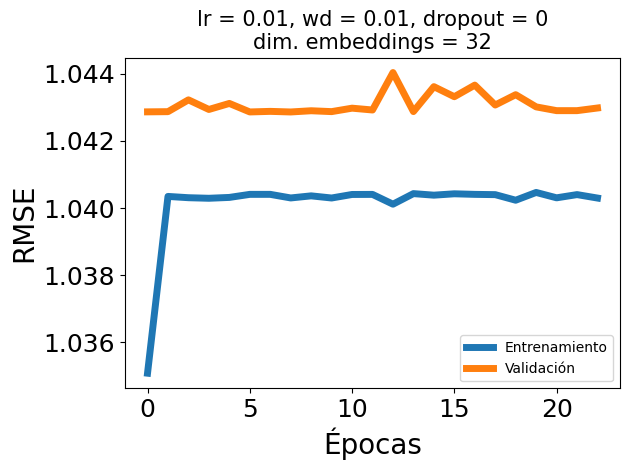

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


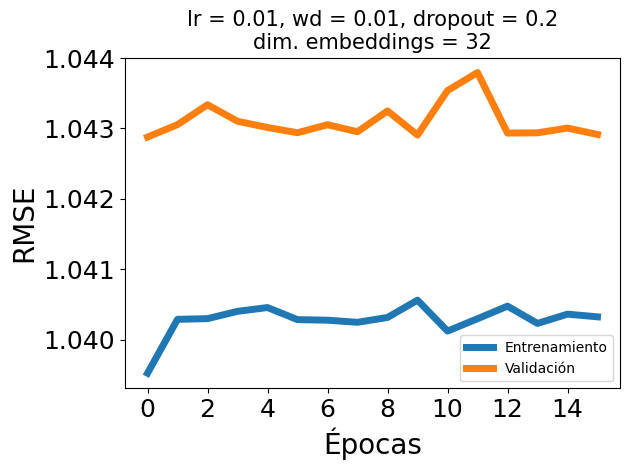

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 21


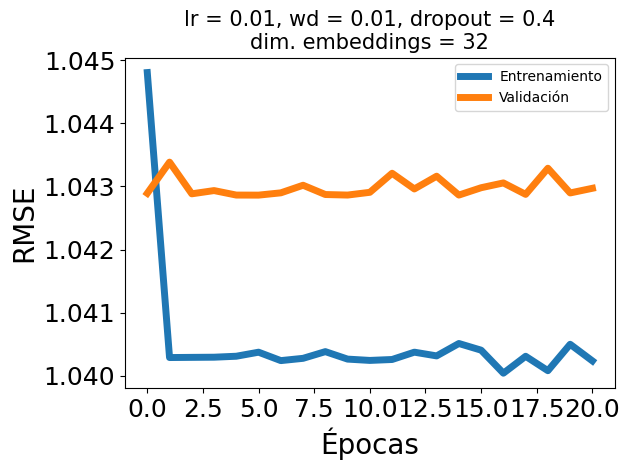

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.024 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 30 |Train Loss: 0.023 | Val Loss: 0.030
Early stopping en la época: 31


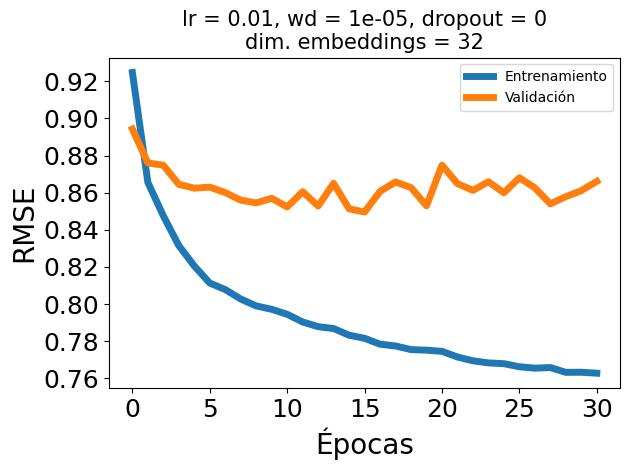

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 30 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 35 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 40 |Train Loss: 0.026 | Val Loss: 0.031
Epoch 45 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 50 |Train Loss: 0.026 | Val Loss: 0.030
Early stopping en la época: 51


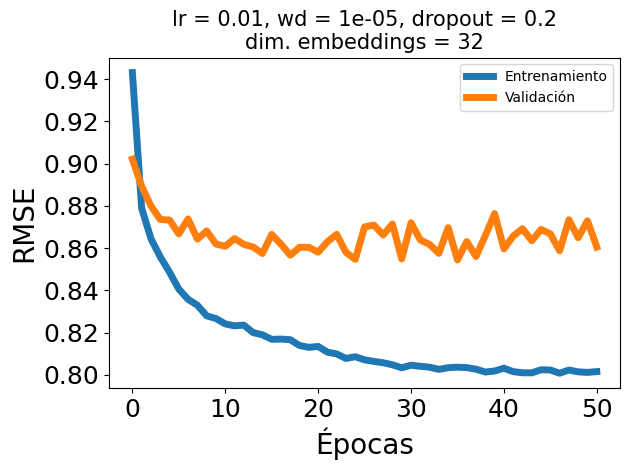

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.030 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.028 | Val Loss: 0.031
Epoch 20 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 30 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 35 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 40 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 45 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 50 |Train Loss: 0.028 | Val Loss: 0.031
Epoch 55 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 60 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 65 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 70 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 75 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 80 |Train Loss: 0.027 | Val Loss: 0.030
Early stopping en la época: 84


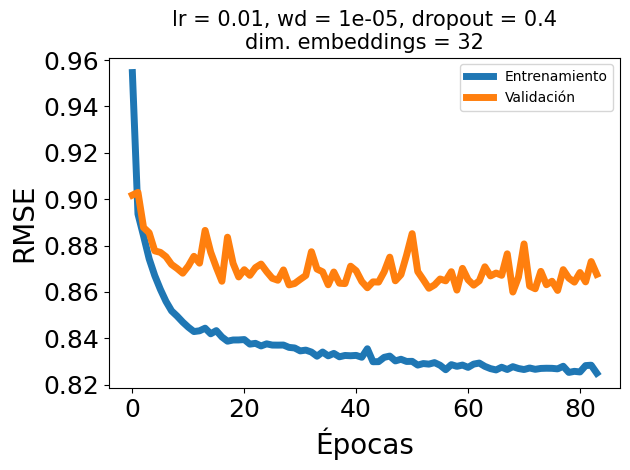

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.034
Epoch 15 |Train Loss: 0.015 | Val Loss: 0.038
Early stopping en la época: 19


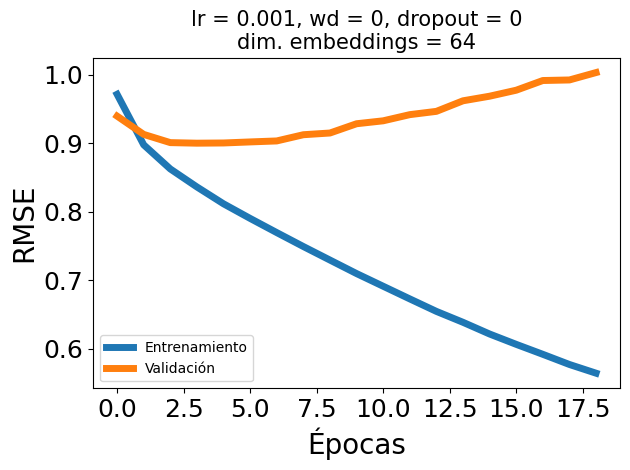

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.023 | Val Loss: 0.032
Epoch 20 |Train Loss: 0.021 | Val Loss: 0.033
Early stopping en la época: 23


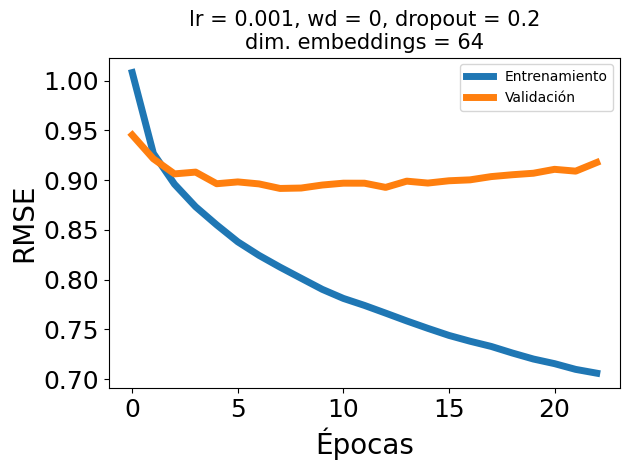

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.031 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 20 |Train Loss: 0.024 | Val Loss: 0.033
Epoch 25 |Train Loss: 0.023 | Val Loss: 0.033
Early stopping en la época: 28


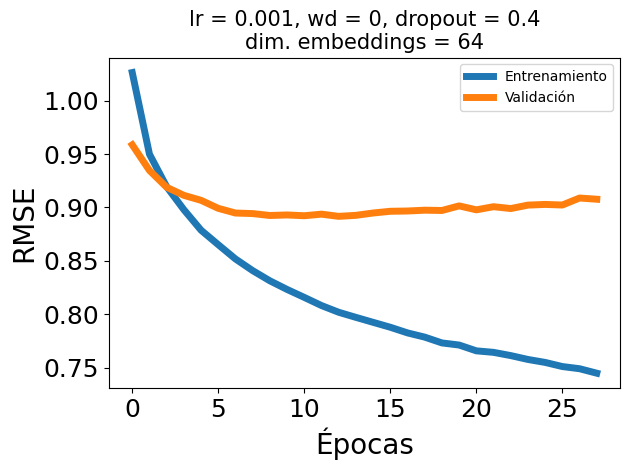

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


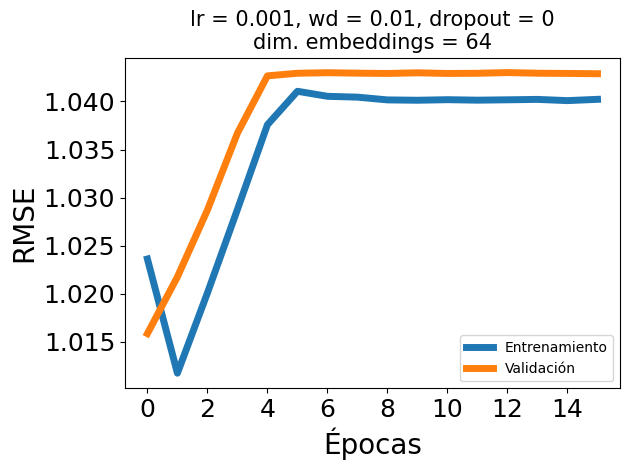

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


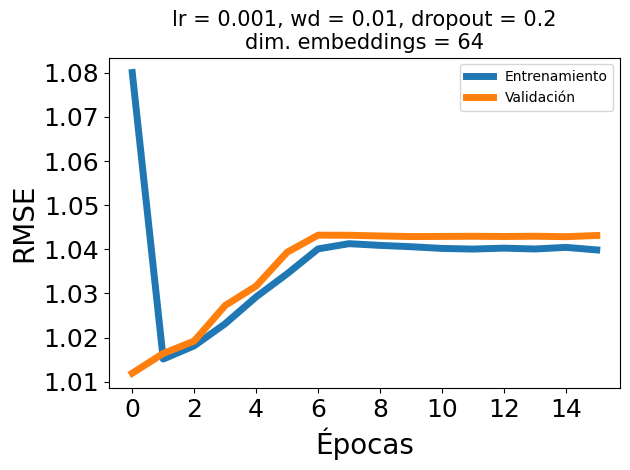

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


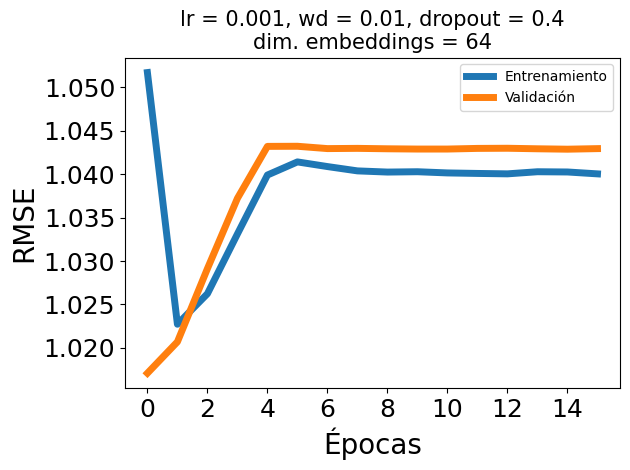

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.018 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.011 | Val Loss: 0.037
Epoch 20 |Train Loss: 0.008 | Val Loss: 0.038
Early stopping en la época: 21


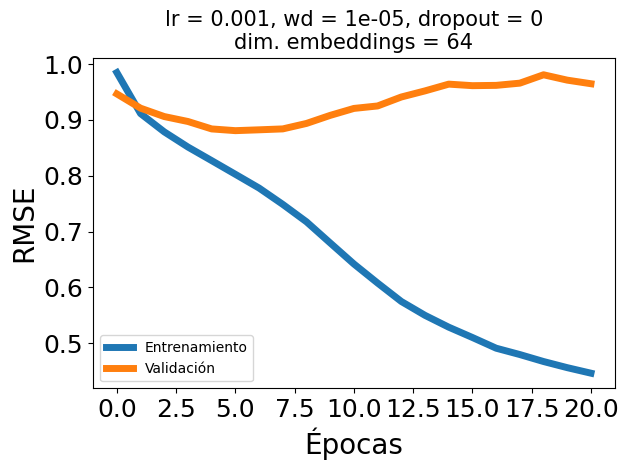

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.018 | Val Loss: 0.031
Epoch 20 |Train Loss: 0.015 | Val Loss: 0.032
Epoch 25 |Train Loss: 0.014 | Val Loss: 0.033
Early stopping en la época: 25


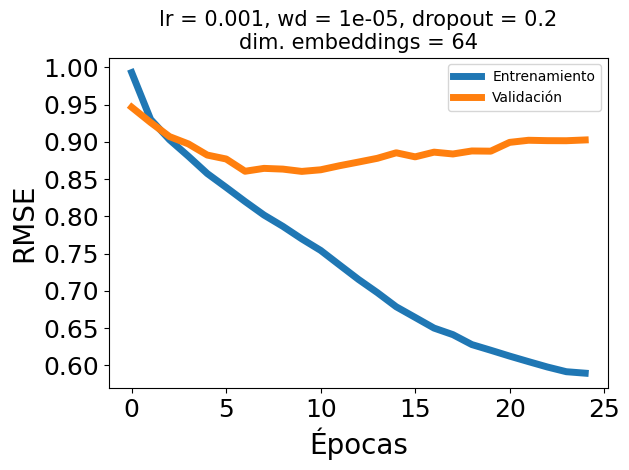

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.031 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.022 | Val Loss: 0.031
Epoch 25 |Train Loss: 0.020 | Val Loss: 0.030
Early stopping en la época: 29


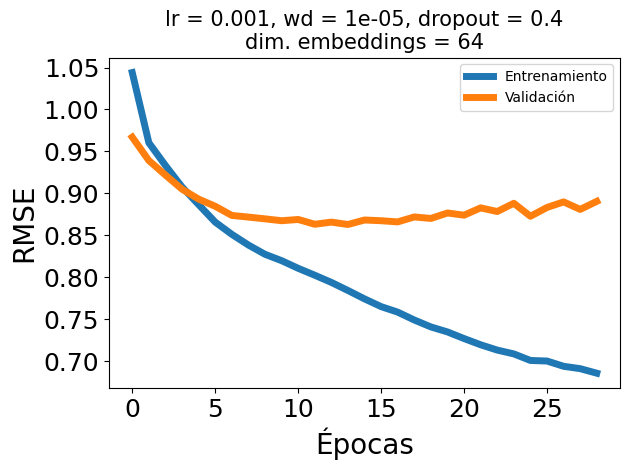

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.022 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.014 | Val Loss: 0.038
Epoch 15 |Train Loss: 0.009 | Val Loss: 0.041
Early stopping en la época: 18


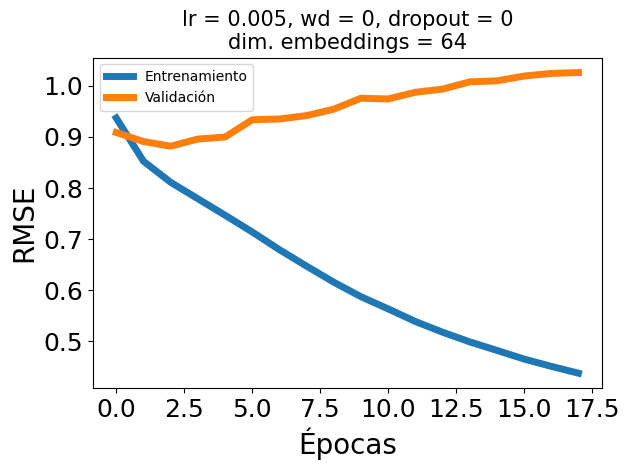

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.035
Epoch 15 |Train Loss: 0.017 | Val Loss: 0.035
Early stopping en la época: 18


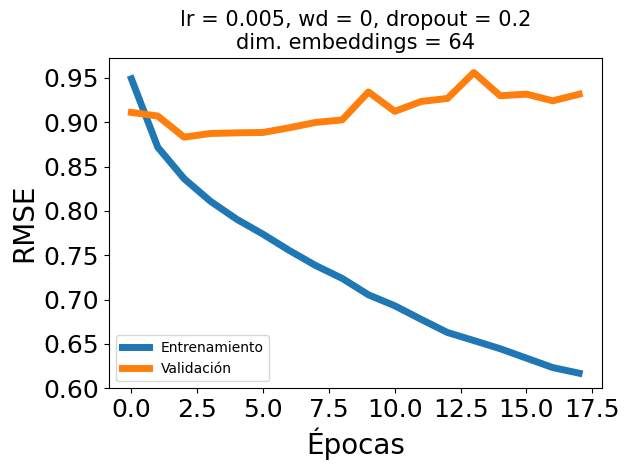

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.033
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.022 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.020 | Val Loss: 0.033
Early stopping en la época: 21


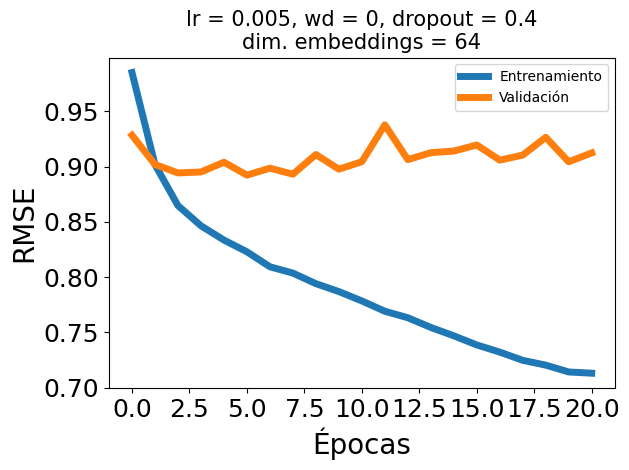

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


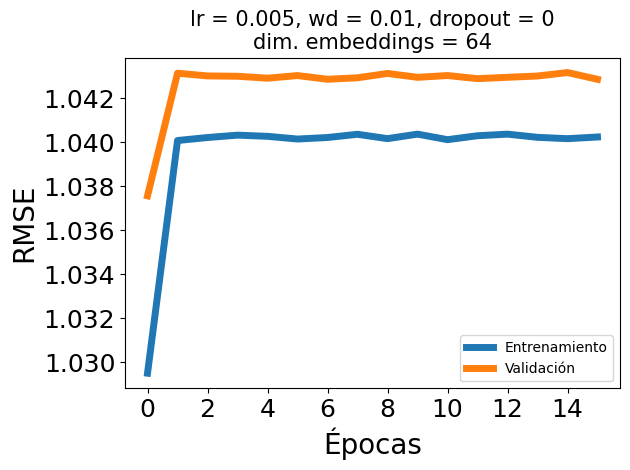

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


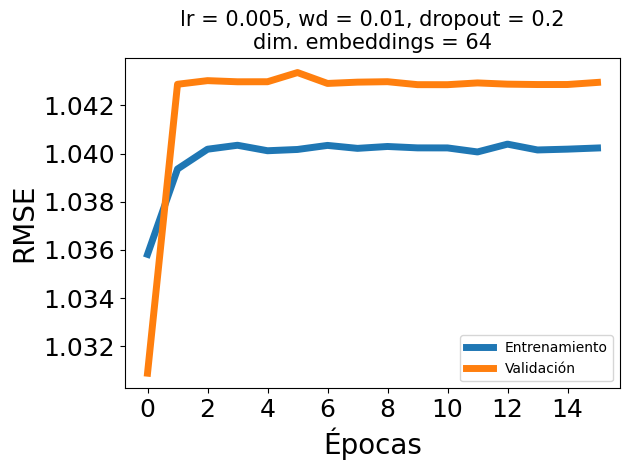

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


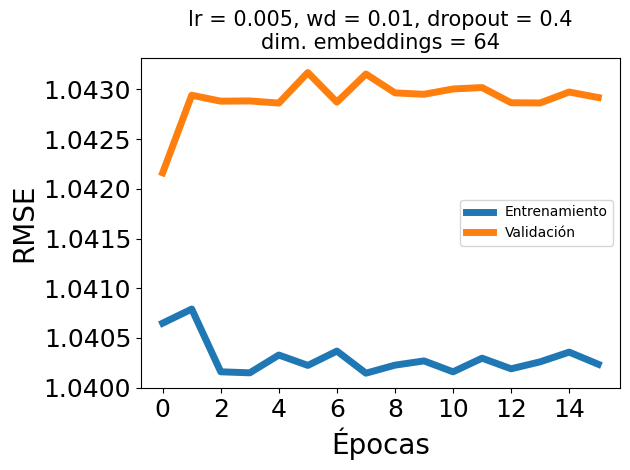

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.020 | Val Loss: 0.031
Epoch 20 |Train Loss: 0.018 | Val Loss: 0.034
Early stopping en la época: 21


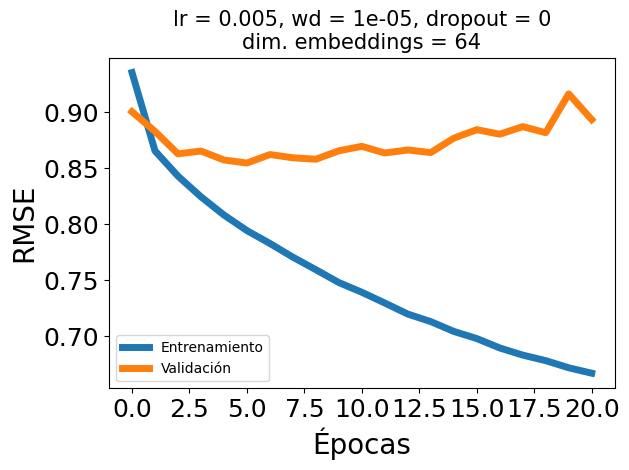

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.023 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.022 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.021 | Val Loss: 0.031
Early stopping en la época: 27


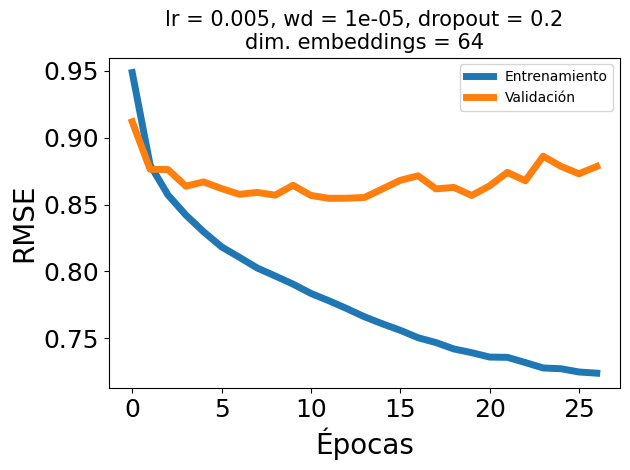

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.024 | Val Loss: 0.030
Early stopping en la época: 28


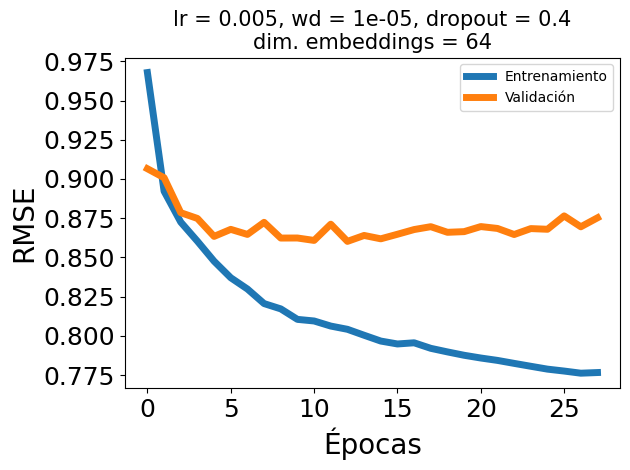

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.021 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.012 | Val Loss: 0.038
Epoch 15 |Train Loss: 0.008 | Val Loss: 0.039
Early stopping en la época: 18


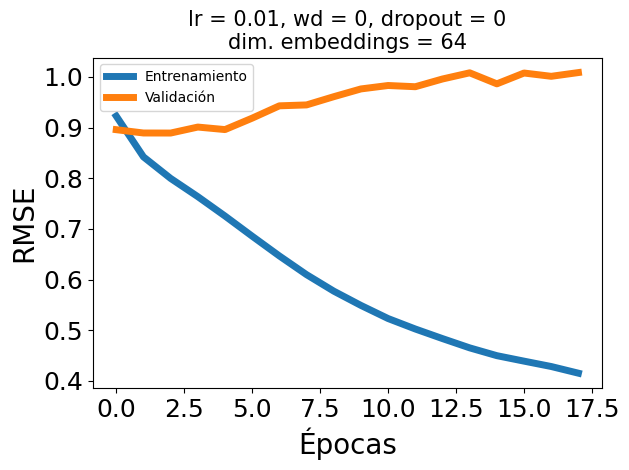

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.017 | Val Loss: 0.035
Epoch 20 |Train Loss: 0.015 | Val Loss: 0.036
Early stopping en la época: 20


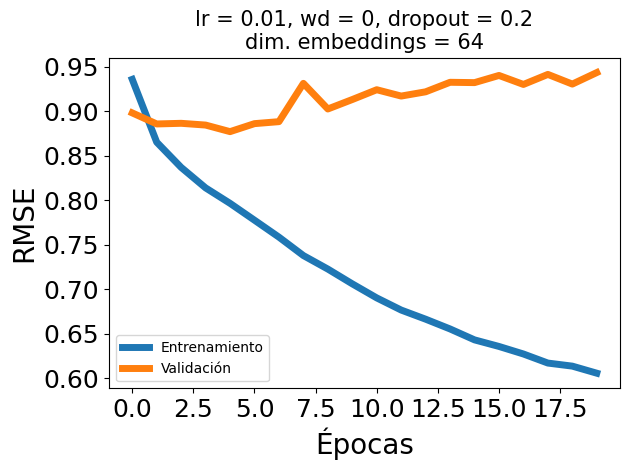

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.023 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.021 | Val Loss: 0.034
Early stopping en la época: 21


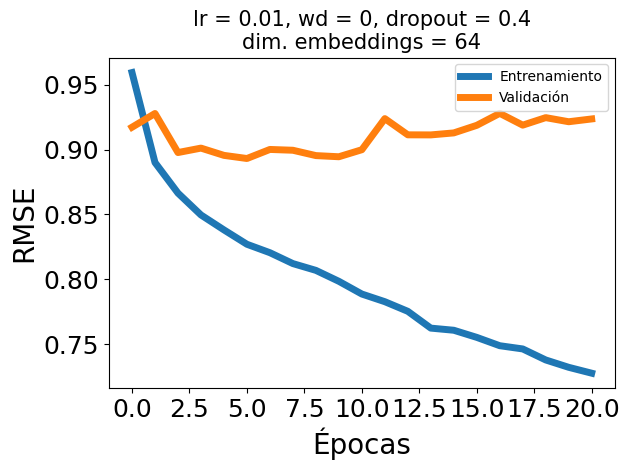

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 25


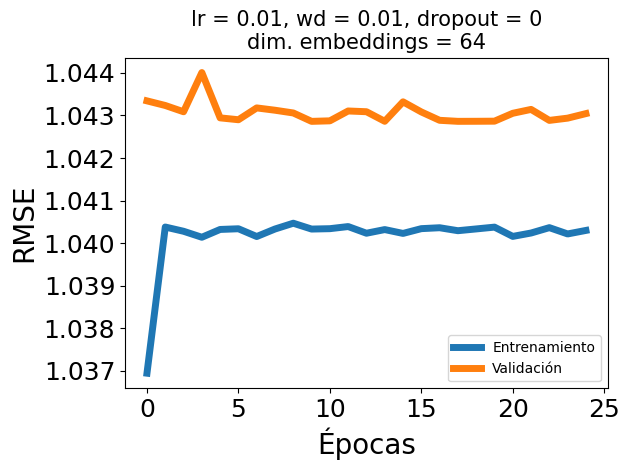

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 24


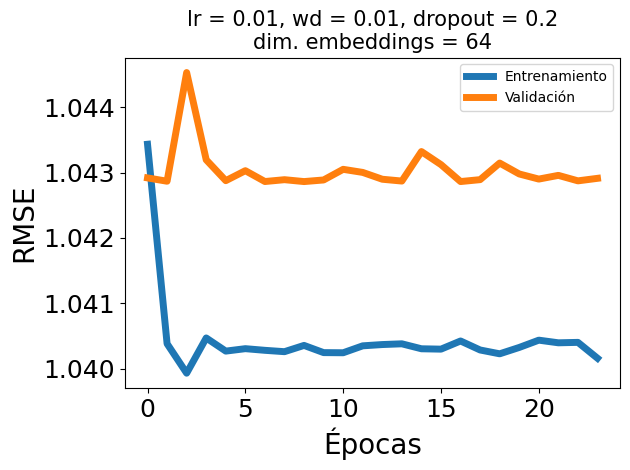

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 16


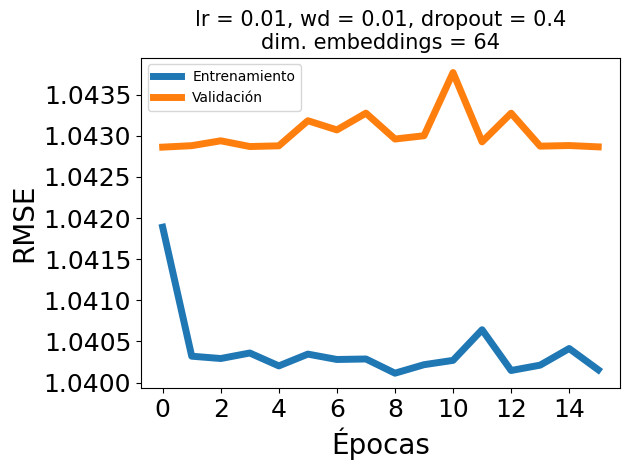

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.025 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.024 | Val Loss: 0.030
Early stopping en la época: 28


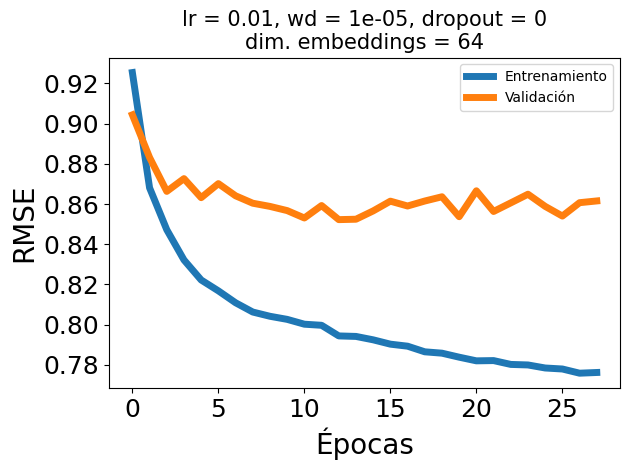

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 30 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 35 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 40 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 45 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 50 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 55 |Train Loss: 0.026 | Val Loss: 0.030
Early stopping en la época: 59


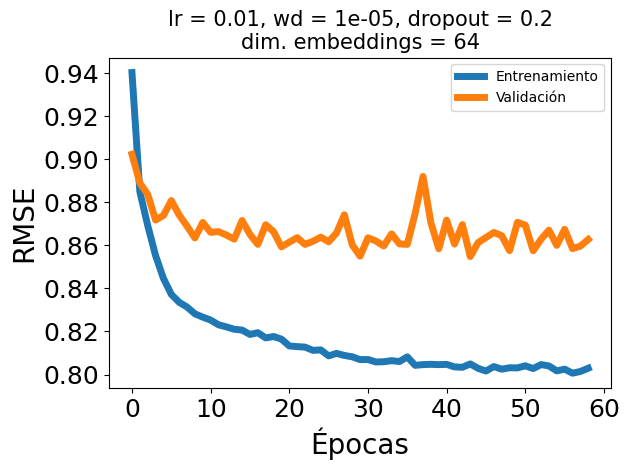

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.031 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 30 |Train Loss: 0.029 | Val Loss: 0.031
Epoch 35 |Train Loss: 0.028 | Val Loss: 0.031
Epoch 40 |Train Loss: 0.028 | Val Loss: 0.030
Early stopping en la época: 44


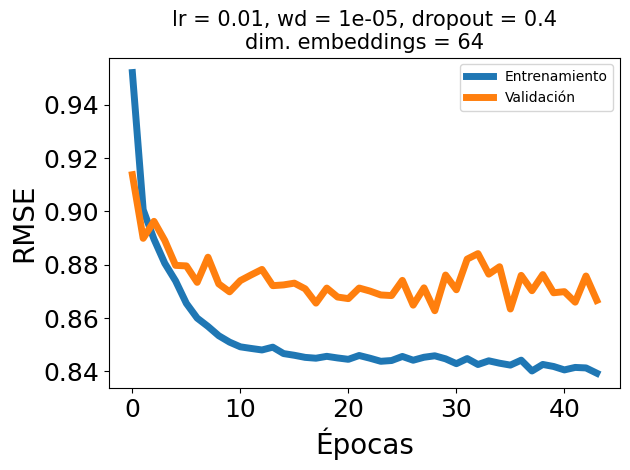

In [33]:
resultados_train =[] 
n=0
for tam_embedd in [32,64]:
    for lr in [1e-3,5e-3,1e-2]:
        for wd in [0,1e-2, 1e-5]:
            for drop in [0,0.2,0.4]:
                best_model,best_val, train_graf,val_graf, epoca_parada = entrenaRed(lr=lr,wd=wd, dropout=drop, epoca = 100, early_stop= 15,tam_embedd =tam_embedd)
                
                graf = graficaEntrenamiento(train_graf,val_graf,lr,wd,drop,n,tam_embedd)
                param_train = {
                    "lr":      lr,
                    "wd":      wd,
                    "dropout": drop,
                    "epoca_parada": epoca_parada ,
                    'tam_embeddings':tam_embedd,
                    "best_RMSE_val":best_val,
                    "grafica" : graf
                }
                resultados_train.append(param_train)
                n+=1

Se recopilan los resultados de todas las combinaciones en una tabla, se añade el RMSE en la escala original del rating, y se guarda en un csv.

In [34]:
tabla_resultados = pd.DataFrame(resultados_train)
tabla_resultados.sort_values(['best_RMSE_val'])
tabla_resultados['RMSE_original']= (tabla_resultados['best_RMSE_val']**0.5)*5

tabla_resultados.to_csv("resultadosRNhybridMenos.csv", index=False)

Se ordenan las combinaciones de mejor a peor RMSE de validación. La mejor combinación usa dimensión de embedding 32, lr=0.005, wd=0.00001, dropout=0, con RMSE ≈ 0.849, ligeramente peor que el 0.824 obtenido en RNhybrid.ipynb con todas las variables de TMDB.

In [35]:
tabla_resultados.sort_values(['best_RMSE_val'])

,lr,wd,dropout,epoca_parada,tam_embeddings,best_RMSE_val,grafica,RMSE_original
15,0.005,0.00001,0.0,22,32,0.028821,15.png,0.848838
24,0.010,0.00001,0.0,31,32,0.028872,24.png,0.849595
51,0.010,0.00001,0.0,28,64,0.029051,51.png,0.852223
16,0.005,0.00001,0.2,26,32,0.029187,16.png,0.854208
25,0.010,0.00001,0.2,51,32,0.029202,25.png,0.854431
43,0.005,0.00001,0.2,27,64,0.029216,43.png,0.854629
42,0.005,0.00001,0.0,21,64,0.029226,42.png,0.854774
52,0.010,0.00001,0.2,59,64,0.029227,52.png,0.854801
8,0.001,0.00001,0.4,29,32,0.029273,8.png,0.855467
7,0.001,0.00001,0.2,26,32,0.029508,7.png,0.858897


## Reentrenamiento final y evaluación
Con la mejor configuración de hiperparámetros, entrenaRedCompleta reentrena el modelo desde cero usando train+val (dataloader_train_val), esta vez sin conjunto de validación ni early stopping, durante un número fijo de épocas.

In [36]:
def  entrenaRedCompleta(lr,wd,dropout,epoca,embedDim):
    criterion = nn.MSELoss()
    model =NCF(numUsers,numItems,numVar,dropout,embedDim) 
    optimizer =optim.Adam(model.parameters(), lr=lr,weight_decay=wd)
    
    for epoch in range(epoca):
        model.train()
        train_loss = 0
        for user, item, X,y in dataloader_train_val:
            optimizer.zero_grad()
            pred= model(user, item,X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dataloader_train_val)
        
        if (epoch + 1) %5 ==0:
            print(f"Epoch {epoch+1} |Train Loss: {train_loss:.3f} ")
            
        
    return  model

evaluacion llama a entrenaRedCompleta y, una vez entrenado el modelo final, calcula el RMSE y el MAE sobre el conjunto de test (deshaciendo la normalización, multiplicando por 5).

In [37]:
def evaluacion (lr,wd,dropout,epoca,embedDim):
    final_model = entrenaRedCompleta(lr,wd,dropout,epoca,embedDim)
    
    criterion = nn.MSELoss()
    final_model.eval()
    test_loss = 0
    test_mae = 0
    with torch.no_grad():
        for user, item, X,y in dataloader_test:
            pred = final_model(user,item,X)
            loss = criterion(pred, y)
            test_loss += loss.item()
            test_mae += torch.abs(pred - y).mean().item()
    mse = test_loss / len(dataloader_test)
    rmse = (mse ** 0.5) * 5.0
    mae = (test_mae / len(dataloader_test)) * 5.0
    print("Test RMSE:", rmse)
    print("Test MAE:", mae)

    return final_model, rmse

Se reentrena y evalúa con la mejor configuración encontrada (lr=0.005, wd=0.00001, dropout=0, embedDim=32, 22 épocas).

In [38]:
evaluacion(lr=0.005, wd=0.00001,dropout=0, epoca=22, embedDim=32)

Epoch 5 |Train Loss: 0.026 
Epoch 10 |Train Loss: 0.023 
Epoch 15 |Train Loss: 0.021 
Epoch 20 |Train Loss: 0.020 
Test RMSE: 0.8695701909643003
Test MAE: 0.6602382179545729


(NCF(
   (user_embedding): Embedding(610, 32)
   (item_embedding): Embedding(9598, 32)
   (fc1): Linear(in_features=86, out_features=64, bias=True)
   (fc2): Linear(in_features=64, out_features=32, bias=True)
   (fc3): Linear(in_features=32, out_features=1, bias=True)
   (relu): ReLU()
   (dropout): Dropout(p=0, inplace=False)
   (sigmoid): Sigmoid()
 ),
 0.8695701909643003)

## Resumen
El RMSE de test de esta versión reducida es 0.8696, algo peor que el 0.8468 de RNhybrid.ipynb (con popularity, vote_average y vote_count incluidas). Esto sugiere que esas tres variables sí aportan información útil al modelo, aunque la diferencia no es muy grande.